# Autovalores Reais e Distintos

Se $A$ ($n\times n$) tem $n$ autovalores reais e distintos $\lambda_1,\dots,\lambda_n$, com autovetores $\mathbf{v}^{(1)},\dots,\mathbf{v}^{(n)}$, esses autovetores são automaticamente linearmente independentes (vimos isso na aula de autovalores), e a solução geral é

$$
\mathbf{x}(t) = c_1\mathbf{v}^{(1)}e^{\lambda_1t} + c_2\mathbf{v}^{(2)}e^{\lambda_2t} + \cdots + c_n\mathbf{v}^{(n)}e^{\lambda_nt}.
$$

É o caso mais simples, e também o que tem a interpretação geométrica mais clara: cada autovetor define uma **reta invariante** pela origem. Uma solução que começa sobre um autovetor $\mathbf{v}$ fica sempre sobre essa reta, afastando-se da origem se $\lambda>0$ ou aproximando-se dela se $\lambda<0$.

Vamos usar uma função auxiliar para desenhar retratos de fase, com os autovetores em tracejado:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

def retrato(A, ax, lim=3, titulo=None, autovetores=True):
    # Desenha o retrato de fase de x' = A x no quadrado [-lim, lim]^2
    A = np.array(A, dtype=float)
    s = np.linspace(-lim, lim, 40)
    X, Y = np.meshgrid(s, s)
    U = A[0, 0]*X + A[0, 1]*Y
    V = A[1, 0]*X + A[1, 1]*Y
    ax.streamplot(X, Y, U, V, color='0.55', density=1.1, linewidth=0.8, arrowsize=1)
    if autovetores:
        lam, vec = np.linalg.eig(A)
        if np.all(np.abs(lam.imag) < 1e-12):
            pares = list(zip(lam.real, vec.T.real))
            if abs(lam[0] - lam[1]) < 1e-6:
                pares = pares[:1]
            for l, v in pares:
                ax.plot([-3*lim*v[0], 3*lim*v[0]], [-3*lim*v[1], 3*lim*v[1]],
                        '--', linewidth=2, label=fr'$\lambda={l:.3g}$')
            ax.legend(loc='lower right', fontsize=8)
    ax.plot(0, 0, 'ko', markersize=5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    if titulo:
        ax.set_title(titulo)

def trajetoria(A, x0, T, ax, cor='b'):
    # Integra x' = A x a partir de x0 e desenha a trajetória
    A = np.array(A, dtype=float)
    sol = solve_ivp(lambda t, x: A @ x, (0, T), x0, max_step=T/500)
    ax.plot(sol.y[0], sol.y[1], color=cor, linewidth=2.5)
    ax.plot(x0[0], x0[1], 'o', color=cor, markersize=7)
    return sol

### Exemplo 1: autovalores de sinais opostos (sela)

Resolva

$$
\mathbf{x}' = \begin{pmatrix} 1 & 1\\ 4 & 1\end{pmatrix}\mathbf{x}, \qquad \mathbf{x}(0) = \begin{pmatrix} 2\\ 0\end{pmatrix}.
$$

**Autovalores:** $\operatorname{tr}A=2$ e $\det A=1-4=-3$, então

$$
\lambda^2 - 2\lambda - 3 = (\lambda-3)(\lambda+1) = 0 \quad\Longrightarrow\quad \lambda_1=3,\ \ \lambda_2=-1.
$$

**Autovetores:** para $\lambda_1=3$, $(A-3I)\mathbf{v}=\begin{pmatrix} -2 & 1\\ 4 & -2\end{pmatrix}\mathbf{v}=\mathbf{0}$ dá $v_2=2v_1$, ou seja, $\mathbf{v}^{(1)}=\begin{pmatrix} 1\\ 2\end{pmatrix}$. Para $\lambda_2=-1$, $(A+I)\mathbf{v}=\begin{pmatrix} 2 & 1\\ 4 & 2\end{pmatrix}\mathbf{v}=\mathbf{0}$ dá $v_2=-2v_1$, ou seja, $\mathbf{v}^{(2)}=\begin{pmatrix} 1\\ -2\end{pmatrix}$.

**Solução geral:**

$$
\mathbf{x}(t) = c_1\begin{pmatrix} 1\\ 2\end{pmatrix}e^{3t} + c_2\begin{pmatrix} 1\\ -2\end{pmatrix}e^{-t}.
$$

**Condição inicial:** em $t=0$, $c_1\begin{pmatrix} 1\\ 2\end{pmatrix}+c_2\begin{pmatrix} 1\\ -2\end{pmatrix}=\begin{pmatrix} 2\\ 0\end{pmatrix}$, ou seja, $c_1+c_2=2$ e $2c_1-2c_2=0$. Logo $c_1=c_2=1$ e

$$
\mathbf{x}(t) = \begin{pmatrix} 1\\ 2\end{pmatrix}e^{3t} + \begin{pmatrix} 1\\ -2\end{pmatrix}e^{-t} = \begin{pmatrix} e^{3t}+e^{-t}\\ 2e^{3t}-2e^{-t}\end{pmatrix}.
$$

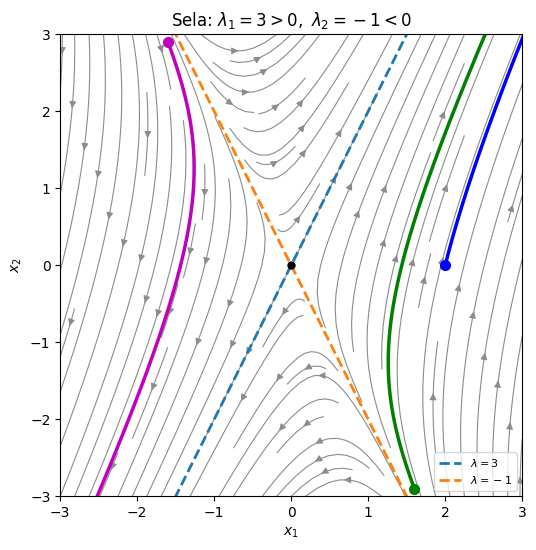

In [2]:
A = np.array([[1, 1], [4, 1]])

fig, ax = plt.subplots(figsize=(6, 6))
retrato(A, ax, lim=3, titulo=r"Sela: $\lambda_1=3>0,\ \lambda_2=-1<0$")
trajetoria(A, [2, 0], 0.3, ax, cor='b')
trajetoria(A, [1.6, -2.9], 1.3, ax, cor='g')
trajetoria(A, [-1.6, 2.9], 1.3, ax, cor='m')
plt.show()

Repare no desenho:

* Sobre a reta do autovetor $\mathbf{v}^{(2)}=(1,-2)$ (com $\lambda_2=-1<0$), as soluções **vão para** a origem.
* Sobre a reta de $\mathbf{v}^{(1)}=(1,2)$ (com $\lambda_1=3>0$), as soluções **fogem** da origem.
* Qualquer outra solução (como a verde e a magenta) chega perto da origem vindo pela direção de $\mathbf{v}^{(2)}$, mas acaba sendo empurrada para longe pela direção de $\mathbf{v}^{(1)}$: quando $t\to\infty$, o termo $e^{3t}$ domina e $\mathbf{x}(t)\approx c_1\mathbf{v}^{(1)}e^{3t}$. A solução do nosso PVI (azul) começa longe da reta de $\mathbf{v}^{(2)}$ e foge quase imediatamente.

Esse retrato de fase é chamado de **ponto de sela** (lembra as curvas de nível de uma sela de cavalo). A origem é **instável**: basta um pequeno desvio para fora da reta de $\mathbf{v}^{(2)}$ para a solução fugir.

### Exemplo 2: dois autovalores negativos (nó estável)

Encontre a solução geral de

$$
\mathbf{x}' = \begin{pmatrix} -4 & 1\\ 2 & -3\end{pmatrix}\mathbf{x}.
$$

Aqui $\operatorname{tr}A=-7$ e $\det A=12-2=10$:

$$
\lambda^2+7\lambda+10 = (\lambda+2)(\lambda+5) = 0 \quad\Longrightarrow\quad \lambda_1=-2,\ \ \lambda_2=-5.
$$

Para $\lambda_1=-2$: $(A+2I)\mathbf{v}=\begin{pmatrix} -2 & 1\\ 2 & -1\end{pmatrix}\mathbf{v}=\mathbf{0}$, então $\mathbf{v}^{(1)}=\begin{pmatrix} 1\\ 2\end{pmatrix}$. Para $\lambda_2=-5$: $(A+5I)\mathbf{v}=\begin{pmatrix} 1 & 1\\ 2 & 2\end{pmatrix}\mathbf{v}=\mathbf{0}$, então $\mathbf{v}^{(2)}=\begin{pmatrix} 1\\ -1\end{pmatrix}$. A solução geral é

$$
\mathbf{x}(t) = c_1\begin{pmatrix} 1\\ 2\end{pmatrix}e^{-2t} + c_2\begin{pmatrix} 1\\ -1\end{pmatrix}e^{-5t}.
$$

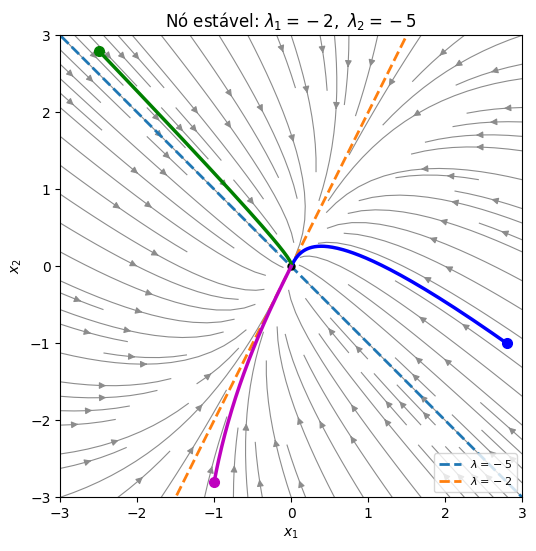

In [3]:
A = np.array([[-4, 1], [2, -3]])

fig, ax = plt.subplots(figsize=(6, 6))
retrato(A, ax, lim=3, titulo=r"Nó estável: $\lambda_1=-2,\ \lambda_2=-5$")
for x0, cor in [([2.8, -1], 'b'), ([-2.5, 2.8], 'g'), ([-1, -2.8], 'm')]:
    trajetoria(A, x0, 4, ax, cor=cor)
plt.show()

Agora as duas exponenciais decaem, e **todas** as soluções vão para a origem: ela é **assintoticamente estável**. Esse retrato é chamado de **nó estável**.

Repare num detalhe: as trajetórias chegam à origem **tangentes ao autovetor de $\lambda_1=-2$**, o autovalor "mais lento". Como $e^{-5t}$ morre muito mais rápido que $e^{-2t}$, depois de pouco tempo sobra $\mathbf{x}(t)\approx c_1\mathbf{v}^{(1)}e^{-2t}$: a solução se alinha com a direção lenta. (É exatamente isso que acontece no modelo de leucemia, como veremos na aula de aplicações.)

Se os dois autovalores fossem **positivos**, o desenho seria o mesmo, com as setas invertidas: todas as soluções fugiriam da origem, num **nó instável**. (Trocar $A$ por $-A$ troca o sinal dos autovalores e inverte o sentido do tempo.)

### Exemplo 3: um sistema $3\times3$

Encontre a solução geral de

$$
\mathbf{x}' = \begin{pmatrix} 0 & 1 & 1\\ 1 & 0 & 1\\ 1 & 1 & 0\end{pmatrix}\mathbf{x}.
$$

Já calculamos os autovalores e autovetores dessa matriz na aula de autovalores: $\lambda_1=2$, com $\mathbf{v}^{(1)}=(1,1,1)$, e o autovalor duplo $\lambda_2=\lambda_3=-1$, com **dois** autovetores independentes, $\mathbf{v}^{(2)}=(1,0,-1)$ e $\mathbf{v}^{(3)}=(0,1,-1)$. Os autovalores não são todos distintos, mas isso não atrapalha: temos três autovetores LI, que dão três soluções independentes:

$$
\mathbf{x}(t) = c_1\begin{pmatrix} 1\\ 1\\ 1\end{pmatrix}e^{2t} + c_2\begin{pmatrix} 1\\ 0\\ -1\end{pmatrix}e^{-t} + c_3\begin{pmatrix} 0\\ 1\\ -1\end{pmatrix}e^{-t}.
$$

Como $\lambda_1=2>0$, a origem é **instável**. Mas repare: as soluções com $c_1=0$, que começam no plano gerado por $\mathbf{v}^{(2)}$ e $\mathbf{v}^{(3)}$ (o plano $x_1+x_2+x_3=0$), ficam nesse plano e vão para a origem. É a versão em três dimensões de uma sela.

## Resumo: autovalores reais e distintos ($2\times2$)

A solução geral é $\mathbf{x}(t)=c_1\mathbf{v}^{(1)}e^{\lambda_1t}+c_2\mathbf{v}^{(2)}e^{\lambda_2t}$, e o retrato de fase depende dos sinais dos autovalores:

| Autovalores | Retrato de fase | Estabilidade da origem |
|---|---|---|
| $\lambda_1<0<\lambda_2$ | sela | instável |
| $\lambda_1,\lambda_2<0$ | nó estável | assintoticamente estável |
| $\lambda_1,\lambda_2>0$ | nó instável | instável |

**Ligação com traço e determinante.** Como $\lambda_1+\lambda_2=\operatorname{tr}A$ e $\lambda_1\lambda_2=\det A$, nem precisamos calcular os autovalores para saber o tipo. Os autovalores são reais e distintos quando $\Delta=(\operatorname{tr}A)^2-4\det A>0$, e então:

* $\det A<0$: autovalores de sinais opostos, **sela**;
* $\det A>0$ e $\operatorname{tr}A<0$: os dois negativos, **nó estável**;
* $\det A>0$ e $\operatorname{tr}A>0$: os dois positivos, **nó instável**.

Confira nos exemplos: no Exemplo 1, $\det A=-3<0$ (sela); no Exemplo 2, $\det A=10>0$ e $\operatorname{tr}A=-7<0$ (nó estável).